### 2.1 导入数据的方法

创建kNN.py文件，并添加如下代码：

```
from numpy import *
import operator

def createDataSet():
    group = array([[1.0,1.0],[1.0,1.0],[0,0]])
    labels = ['A','A','B','B']
    return group, labels
```

In [14]:
import kNN

In [15]:
group, labels = kNN.createDataSet()

In [16]:
group

array([[1., 1.],
       [1., 1.],
       [0., 0.]])

In [17]:
labels

['A', 'A', 'B', 'B']

In [18]:
kNN.classify0([0,0],group,labels,3)

'A'

### 2.2 示例：改进约会网站配对效果

#### (1) 导入数据

在kNN.py中增加如下代码，将文件数据读取到内存中（矩阵数据）

```
def file2matrix(filename):
    fr = open(filename)
    arrayofLines = fr.readlines()
    numberofLines = len(arrayofLines) # 获得文件行数（样本数）
    returnMat = zeros((numberofLines,3)) # 样本包含3个特征，创建返回的矩阵
    classLabelVector = []
    index = 0
    for line in arrayofLines:
        line = line.strip() # 截取回车字符
        listFromLine = line.split('\t') # 以空格为分隔符做切片
        returnMat[index,:] = listFromLine[0:3] # 将样本数据赋值给矩阵第index行
        classLabelVector.append(int(listFromLine[-1])) # 样本数据最后一位是标签
        
        index += 1
        
    return returnMat, classLabelVector
```

In [19]:
datingDataMat, datingLabels = kNN.file2matrix('./data/datingTestSet2.txt')

In [20]:
datingDataMat

array([[4.0920000e+04, 8.3269760e+00, 9.5395200e-01],
       [1.4488000e+04, 7.1534690e+00, 1.6739040e+00],
       [2.6052000e+04, 1.4418710e+00, 8.0512400e-01],
       ...,
       [2.6575000e+04, 1.0650102e+01, 8.6662700e-01],
       [4.8111000e+04, 9.1345280e+00, 7.2804500e-01],
       [4.3757000e+04, 7.8826010e+00, 1.3324460e+00]])

In [21]:
datingLabels[0:20]

[3, 2, 1, 1, 1, 1, 3, 3, 1, 3, 1, 1, 2, 1, 1, 1, 1, 1, 2, 3]

#### (2) 分析数据

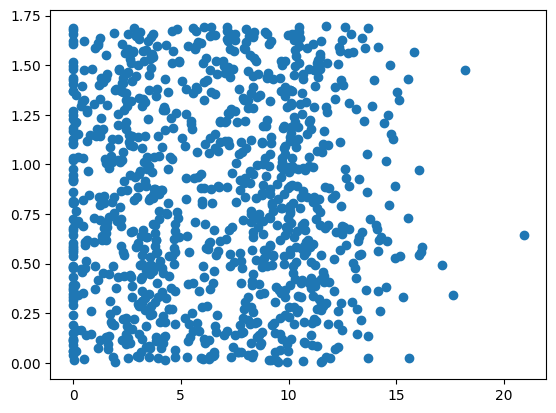

In [22]:
import matplotlib
import matplotlib.pyplot as plt
fig = plt.figure()
ax = fig.add_subplot(111)
ax.scatter(datingDataMat[:,1],datingDataMat[:,2])
plt.show()

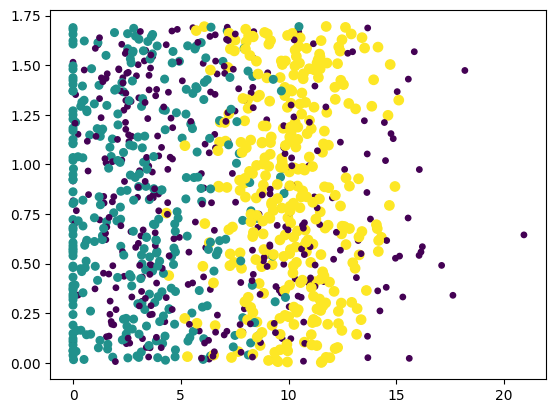

In [29]:
from numpy import array
fig = plt.figure()
ax = fig.add_subplot(111)
ax.scatter(datingDataMat[:,1],datingDataMat[:,2],15*array(datingLabels),15*array(datingLabels))
plt.show()

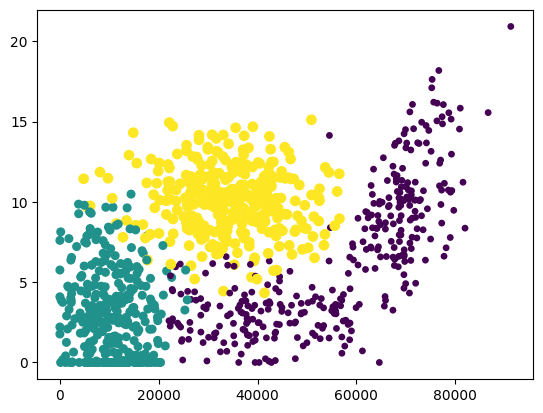

In [30]:
from numpy import array
fig = plt.figure()
ax = fig.add_subplot(111)
ax.scatter(datingDataMat[:,0],datingDataMat[:,1],15*array(datingLabels),15*array(datingLabels))
plt.show()

#### (3) 准备数据（数据处理）

在kNN.py中添加autoNorm函数以归一化数据：
```
def autoNorm(dataSet): # 对各特征进行归一化: newValue = (oldValue - min)/(max-min)
    minVals = dataSet.min(0)  # 取毎列最小值
    maxVals = dataSet.max(0)
    
    ranges = maxVals - minVals # 数据范围
    normDataSet = zeros(shape(dataSet)) # 存储归一化的数据
    m = dataSet.shape[0]
    normDataSet = dataSet - tile(minVals,(m,1)) # tile可以将1*3的minVals转换成1000*3的矩阵
    normDataSet = normDataSet / tile(ranges,(m,1))  # /在numpy中表示点除
    return normDataSet, ranges, minVals
```

In [32]:
import importlib
importlib.reload(kNN)

normMat, ranges, minVals = kNN.autoNorm(datingDataMat)
normMat

array([[0.44832535, 0.39805139, 0.56233353],
       [0.15873259, 0.34195467, 0.98724416],
       [0.28542943, 0.06892523, 0.47449629],
       ...,
       [0.29115949, 0.50910294, 0.51079493],
       [0.52711097, 0.43665451, 0.4290048 ],
       [0.47940793, 0.3768091 , 0.78571804]])

In [33]:
ranges

array([9.1273000e+04, 2.0919349e+01, 1.6943610e+00])

In [34]:
minVals

array([0.      , 0.      , 0.001156])

#### (3) 测试算法

在kNN.py中增加datingClassTest函数以测试分类器错误率
```
def datingClassTest():
    hoRatio = 0.1 # 测试数据占训练样本的百分比
    datingDataMat, datingLabels = file2matrix('./data/datingTestSet.txt')
    normMat, ranges, minVals = autoNorm(datingDataMat)
    m = normMat.shape[0]
    
    numTestVecs = int(m*hoRatio) # 测试数据的样本数
    errorCount = 0.0
    
    for i in range(numTestVecs):
        classifierResult = classify0(normMat[i,:],normMat[numTestVecs:m,:],datingLabels[numTestVecs:m],3)
        print("the classifier came back with: %d, the real answer is: %d" %(classifierResult,datingLabels[i]))
        
        if classifierResult != datingLabels[i]:
            errorCount += 1.0 # 如果分类错误，错误+1
    print("the total error rate is: %f" % (errorCount/float(numTestVecs)))
```

In [40]:
import importlib
importlib.reload(kNN)

kNN.datingClassTest()

the classifier came back with: 3, the real answer is: 3
the classifier came back with: 2, the real answer is: 2
the classifier came back with: 1, the real answer is: 1
the classifier came back with: 1, the real answer is: 1
the classifier came back with: 1, the real answer is: 1
the classifier came back with: 1, the real answer is: 1
the classifier came back with: 3, the real answer is: 3
the classifier came back with: 3, the real answer is: 3
the classifier came back with: 1, the real answer is: 1
the classifier came back with: 3, the real answer is: 3
the classifier came back with: 1, the real answer is: 1
the classifier came back with: 1, the real answer is: 1
the classifier came back with: 2, the real answer is: 2
the classifier came back with: 1, the real answer is: 1
the classifier came back with: 1, the real answer is: 1
the classifier came back with: 1, the real answer is: 1
the classifier came back with: 1, the real answer is: 1
the classifier came back with: 1, the real answe

#### (4) 使用算法

在kNN.py中添加人机交互函数，实时分类：
```
def classifyPerson():
    resultList = ['not at all','in small doses', 'in large doses']
    percentTats = float(input("花在游戏上的时间占比？"))
    ffMiles = float(input("每年飞行里程数？"))
    iceCream = float(input("每周吃多少公升冰淇淋？"))
    
    datingDataMat, datingLabels = file2matrix('./data/datingTestSet2.txt')
    normMat, ranges, minVals = autoNorm(datingDataMat)
    intArray = array([ffMiles,percentTats, iceCream])
    classifierResult = classify0((intArray-minVals)/ranges,normMat,datingLabels,3) # 新的数据也需归一化
    print("这个人的类型是",resultList[classifierResult-1])
```

In [43]:
import importlib
importlib.reload(kNN)

kNN.classifyPerson()

花在游戏上的时间占比？ 0.1
每年飞行里程数？ 0
每周吃多少公升冰淇淋？ 0


这个人的类型是 in small doses
